In [118]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random


# Datasets Used

- 1. Large - USER.csv

- 2. Medium - WIKIPROJECTS.csv

- 3. Small - REQUEST_A_QUERY.csv

#### NETWORK CONSTRUCTION FUNCTIONS FOR THE 3 DATASETS

In [119]:

# --- FUNCTION THAT WILL Build edges based on shared relationship  -----------------------------------
def build_network(df):
    user_col = "username"
    # create nx graph and  Add all unique users in username column as nodes
    graph = nx.Graph()
    for u in df[user_col].unique():
        graph.add_node(u)

    grouped = df.groupby(["page_name", "thread_subject"])

    for _, group in grouped:
        # Unique users in this page+thread
        username = list(group[user_col].dropna().unique())
        n = len(username)
        
        # Double loop to generate all user pairs
        for i in range(n):
            for j in range(i + 1, n):
                u = username[i]
                v = username[j]
                #graph.add_edge(u, v)

                #Add or update weighted edge
                #used for propagation section
                if graph.has_edge(u, v):
                    graph[u][v]["weight"] += 1
                else:
                    graph.add_edge(u, v, weight=1)
    return graph

#----CALCULATE AVG SHORTEST PATH -----------------
def avg_shortest_path(graph):
    largest_cc = max(nx.connected_components(graph))
    lcc_sub = graph.subgraph(largest_cc)
    avg_short_path = nx.average_shortest_path_length(lcc_sub)
    return avg_short_path
#weighted_short_path = nx.shortest_path_length(G, u1, u2, weight=lambda u, v, d: 1 / d["weight"])

#------CALCULATE NUMBER OF NODES----------------
def num_of_nodes(graph):
   return graph.number_of_nodes() 

#-------GET NUMBER OF EDGES----------------
def num_of_edges(graph):
    return (graph.number_of_edges())

#-------GET LIST OF EDGES----------------
def get_edgelist(graph):
    return nx.to_edgelist(graph)

#--------CALCULATE CLUSTERING COEFFICIENT------------
def cluster_coefficient(graph):
    return nx.average_clustering(graph)

#-------GET LIST OF COMPONENTS----------------
def components_list(graph):
    return list(nx.connected_components(graph))

#-------GET EDGE DENSITY----------------
def get_edge_density(graph):
    return nx.density(graph)

# --- Optional cleanup -------------------------------------------------------

# Remove self-loops if any slipped through
#G.remove_edges_from(nx.selfloop_edges(G))


In [120]:
#-------CALCULATE LARGE NETWORK: USERS.CSV---------------------------
#USERS dataset is a talk page where editors talk to their users in their own unique pages
csv_path = r"C:\Users\einob\OneDrive - King's College London\AA - Network Data Analysis\USERS.csv" 

# Read only the needed columns
df_users = pd.read_csv(csv_path)

# 51304 rows with "no subject" as a thread subject will be dropped. result is 120387 rows
df_users = df_users[df_users["thread_subject"] != "No subject"]

users_graph = (build_network(df_users))



In [121]:
#----CALCULATE METRICS FOR USERS.csv
print("Number of Nodes: ", num_of_nodes(users_graph))
print("Number of Edges:" ,num_of_edges(users_graph))
print(f"clustering coefficient: {cluster_coefficient(users_graph):.3f}")
print(f"average Shortest path length is: {avg_shortest_path(users_graph):.3f}")
print(f"number of components: {len(components_list(users_graph)):.3f}")
print(f"Edge Density: {get_edge_density(users_graph):.3f}")

Number of Nodes:  10319
Number of Edges: 23678
clustering coefficient: 0.194
average Shortest path length is: 3.626
number of components: 2714.000
Edge Density: 0.000


In [122]:
#create a list of all the edges in the USERS graph
#creates a list with the two users that have interacted alongside their weight (# of times they have interacted)
UsersNetworkList = nx.to_edgelist(users_graph)

print("Network List: ", get_edgelist(users_graph))

print("List of components: ", components_list(users_graph))



Network List:  [('Vnnen', 'Fralambert', {'weight': 1}), ('Vnnen', 'VIGNERON', {'weight': 1}), ('Noraton', '31.200.17.103', {'weight': 3}), ('Noraton', 'Adeliine', {'weight': 1}), ('Noraton', 'Artahooei1', {'weight': 1}), ('Noraton', 'Alfiya55', {'weight': 1}), ('Noraton', 'Amator linguarum', {'weight': 1}), ('Noraton', 'Camelia.boban', {'weight': 1}), ('Noraton', 'Euro know', {'weight': 1}), ('Noraton', 'Hamid Hassani', {'weight': 1}), ('Noraton', 'Hanooz', {'weight': 1}), ('Noraton', 'Lionster', {'weight': 1}), ('Noraton', 'Braveheart', {'weight': 1}), ('Noraton', 'MX8', {'weight': 1}), ('Noraton', 'Marsupium', {'weight': 1}), ('Noraton', 'Milei.vencel', {'weight': 1}), ('Noraton', '46.219.210.13', {'weight': 1}), ('Noraton', 'PeaceSearcher', {'weight': 2}), ('Noraton', 'Rachmat04', {'weight': 2}), ('Noraton', 'Saeng Petchchai', {'weight': 1}), ('Noraton', 'Soundwaweserb', {'weight': 1}), ('Noraton', 'Szilas', {'weight': 1}), ('Noraton', 'Sîmbotin', {'weight': 1}), ('Noraton', 'Insert

Random Graph Metrics:
Nodes: 10319
Edges: 23560
Clustering coefficient: 0.00030618507699620216
Average path length: 6.232518324379613
Number of components: 113
Edge Density:  0.00044255998711842376


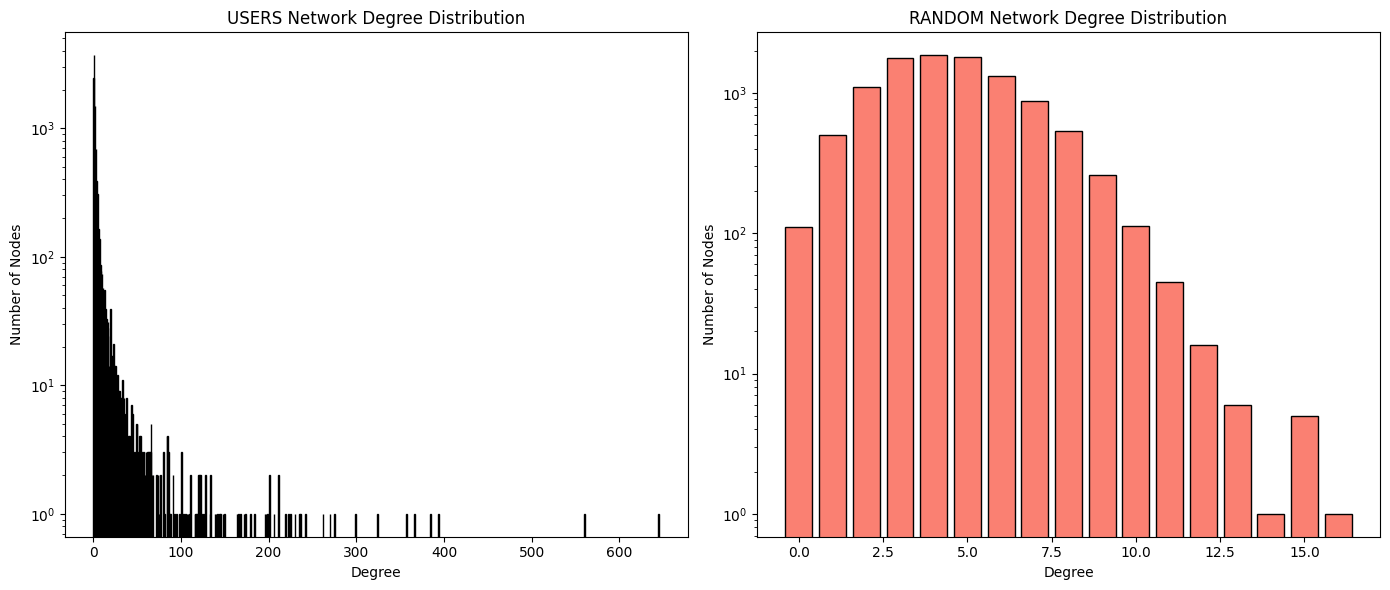

In [123]:
#RANDOM NETWORK COMPARISONS FOR USERS DATASET
# calculate the probability for this dataset

# Parameters from your real network
n = 10319
p = 0.0004447765439299676

# Create Erdős–Rényi random graph
G_random = nx.erdos_renyi_graph(n=n, p=p)

# Compute metrics
rand_nodes = num_of_nodes(G_random)
rand_edges = num_of_edges(G_random)
rand_clustering = cluster_coefficient(G_random)

# Largest connected component for path length
largest_cc = max(nx.connected_components(G_random), key=len)
G_lcc = G_random.subgraph(largest_cc)
rand_path_length = avg_shortest_path(G_lcc)
avg_shortest_path(G_random)

rand_components = nx.number_connected_components(G_random)

print("Random Graph Metrics:")
print("Nodes:", rand_nodes)
print("Edges:", rand_edges)
print("Clustering coefficient:", rand_clustering)
print("Average path length:", rand_path_length)
print("Number of components:", rand_components)
print("Edge Density: ",get_edge_density(G_random))

# ----------- PLOT HISTOGRAMS --------------------

# --- Degree histograms ---
users_hist = nx.degree_histogram(users_graph)
rand_hist = nx.degree_histogram(G_random)

# --- X‑axes (degree values) ---
users_x = list(range(len(users_hist)))
rand_x = list(range(len(rand_hist)))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(users_x, users_hist, color='steelblue', edgecolor='black')
plt.title("USERS Network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 


plt.subplot(1, 2, 2)
plt.bar(rand_x, rand_hist, color='salmon', edgecolor='black')
plt.title("RANDOM Network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 

plt.tight_layout()
plt.show()

In [124]:
csv_path = r"C:\Users\einob\OneDrive - King's College London\AA - Network Data Analysis\WIKIPROJECTS.csv" #WIKIPROJECTS dataset is a talk page where editors talk to their users in their own unique pages

# Adjust these column names to match your file exactly
user_col = "username"
context_cols = ["page_name", "thread_subject"]

# Read only the needed columns
df_project = pd.read_csv(csv_path, usecols=[user_col] + context_cols)

# 177 rows with "no subject" as a thread subject will be dropped. result is 11684 rows
df_project = df_project[df_project["thread_subject"] != "No subject"]
project_graph = (build_network(df_project))

In [125]:
#----CALCULATE METRICS FOR WIKIPROJECTS.csv----------------------------------

print("Number of Nodes:",num_of_nodes(project_graph))
print("Number of Edges:",num_of_edges(project_graph))
print("clustering coefficient: ", cluster_coefficient(project_graph))
print("average path length is: ",avg_shortest_path(project_graph))
print("number of components: ", len(components_list(project_graph)))
print("Edge Density: ", get_edge_density(project_graph))



Number of Nodes: 1593
Number of Edges: 6730
clustering coefficient:  0.5088222675296336
average path length is:  3.14942698080323
number of components:  189
Edge Density:  0.005307453778623185


In [126]:
#create a list of all the edges in the WIKIPROJECT graph
#creates a list with the two users that have interacted alongside their weight (# of times they have interacted)
ProjectNetworkList = nx.to_edgelist(project_graph)

print("Network List: ", ProjectNetworkList)

print("Component list length: ", len(components_list(project_graph)))


Network List:  [('Jneubert', 'Jura1', {'weight': 2}), ('Jneubert', 'Halibutt', {'weight': 1}), ('Jneubert', 'Hazmat2', {'weight': 1}), ('Jneubert', 'Silva Selva', {'weight': 1}), ('Jneubert', 'Sic19', {'weight': 1}), ('Jneubert', 'Epìdosis', {'weight': 2}), ('Jneubert', 'Pigsonthewing', {'weight': 1}), ('Jneubert', 'PKM', {'weight': 1}), ('Jneubert', 'Lea Lacroix (WMDE)', {'weight': 1}), ('Jneubert', 'Pyfisch', {'weight': 1}), ('Jneubert', 'Emu', {'weight': 1}), ('Jneubert', 'Marv1N', {'weight': 1}), ('Jneubert', 'Kolja21', {'weight': 1}), ('Jneubert', 'M2k~dewiki', {'weight': 1}), ('Jneubert', 'Vladimir Alexiev', {'weight': 3}), ('Jneubert', 'GerardM', {'weight': 1}), ('Jneubert', 'Jklamo', {'weight': 1}), ('Jneubert', 'ArthurPSmith', {'weight': 1}), ('Jneubert', 'So9q', {'weight': 1}), ('Jneubert', 'VIGNERON', {'weight': 1}), ('Jneubert', '99of9', {'weight': 1}), ('Jneubert', 'Circeus', {'weight': 1}), ('Jneubert', 'Jheald', {'weight': 1}), ('Jneubert', 'Hsarrazin', {'weight': 1}), (

Random Graph Metrics:
Nodes: 1593
Edges: 6761
Clustering coefficient: 0.005202194113821803
Average path length: 3.685503790137126
Number of components: 1
Edge Density:  0.005331901188301836


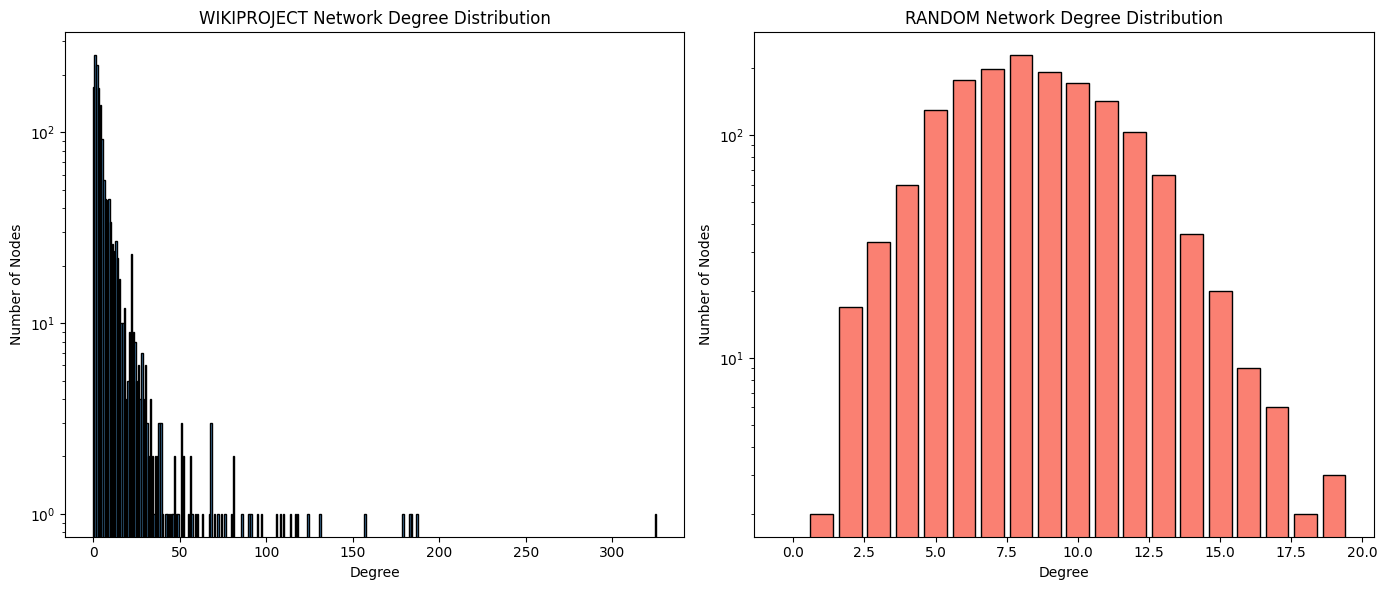

In [127]:
#RANDOM NETWORK COMPARISONS FOR WIKIPROJECT DATASET
# calculate the probability for this dataset

# Parameters from your real network
n = 1593
p = 0.005307453778623185

# Create Erdős–Rényi random graph
G_random = nx.erdos_renyi_graph(n=n, p=p)

# Compute metrics
rand_nodes = num_of_nodes(G_random)
rand_edges = num_of_edges(G_random)
rand_clustering = cluster_coefficient(G_random)

# Largest connected component for path length
largest_cc = max(nx.connected_components(G_random), key=len)
G_lcc = G_random.subgraph(largest_cc)
rand_path_length = avg_shortest_path(G_lcc)
avg_shortest_path(G_random)

rand_components = nx.number_connected_components(G_random)

print("Random Graph Metrics:")
print("Nodes:", rand_nodes)
print("Edges:", rand_edges)
print("Clustering coefficient:", rand_clustering)
print("Average path length:", rand_path_length)
print("Number of components:", rand_components)
print("Edge Density: ",get_edge_density(G_random))


# ----------- PLOT HISTOGRAMS SIDE BY SIDE--------------------

# --- Degree histograms ---
proj_hist = nx.degree_histogram(project_graph)
rand_hist = nx.degree_histogram(G_random)

# --- X‑axes (degree values) ---
proj_x = list(range(len(proj_hist)))
rand_x = list(range(len(rand_hist)))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(proj_x, proj_hist, color='steelblue', edgecolor='black')
plt.title("WIKIPROJECT Network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 


plt.subplot(1, 2, 2)
plt.bar(rand_x, rand_hist, color='salmon', edgecolor='black')
plt.title("RANDOM Network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 

plt.tight_layout()
plt.show()

In [128]:
# --- Load CSV for REQUEST_A_QUERY.csv---------------------------------------------------------------

csv_path = r"C:\Users\einob\OneDrive - King's College London\AA - Network Data Analysis\REQUEST_A_QUERY.csv" #USERS dataset is a talk page where editors talk to their users in their own unique pages

# Adjust these column names to match your file exactly
user_col = "username"
context_cols = ["page_name", "thread_subject"]

# Read only the needed columns
df_request = pd.read_csv(csv_path, usecols=[user_col] + context_cols)

#rows with "no subject" as a thread subject will be dropped. no such rows found. no change
df_request = df_request[df_request["thread_subject"] != "No subject"]
request_graph = (build_network(df_request))

In [129]:
#----CALCULATE METRICS FOR REQUEST_A_QUERY.csv----------------------------------
print("Number of Edges:",num_of_edges(request_graph))
print("Number of Nodes:",num_of_nodes(request_graph))
print("clustering coefficient: ", cluster_coefficient(request_graph))
print("average path length is: ",avg_shortest_path(request_graph))
print("Number of Components: ", len(components_list(request_graph)))
print("Edge Density: ", get_edge_density(request_graph))


Number of Edges: 1884
Number of Nodes: 698
clustering coefficient:  0.5128717931772322
average path length is:  2.511563547422774
Number of Components:  31
Edge Density:  0.007745022671868384


In [130]:
#create a list of all the edges in the REQUEST_A_QUERY graph
#creates a list with the two users that have interacted alongside their weight (# of times they have interacted)
RequestNetworkList = nx.to_edgelist(request_graph)
print("Network List: ", RequestNetworkList)
print("List of components: ", components_list(request_graph))


Network List:  [('Matěj Suchánek', 'Edgars2007', {'weight': 19}), ('Matěj Suchánek', 'Jklamo', {'weight': 7}), ('Matěj Suchánek', 'VIGNERON', {'weight': 11}), ('Matěj Suchánek', 'Pigsonthewing', {'weight': 15}), ('Matěj Suchánek', 'Epìdosis', {'weight': 6}), ('Matěj Suchánek', 'Airon90', {'weight': 5}), ('Matěj Suchánek', 'Jura1', {'weight': 25}), ('Matěj Suchánek', 'Spinster', {'weight': 1}), ('Matěj Suchánek', 'ChristianKl', {'weight': 4}), ('Matěj Suchánek', 'Tobias1984', {'weight': 1}), ('Matěj Suchánek', 'Pasleim', {'weight': 6}), ('Matěj Suchánek', 'Thibaut120094', {'weight': 2}), ('Matěj Suchánek', 'Paucabot', {'weight': 3}), ('Matěj Suchánek', 'TomT0m', {'weight': 2}), ('Matěj Suchánek', 'Micru', {'weight': 2}), ('Matěj Suchánek', 'Vojtěch Dostál', {'weight': 3}), ('Matěj Suchánek', 'Theklan', {'weight': 6}), ('Matěj Suchánek', 'McSearch', {'weight': 3}), ('Matěj Suchánek', 'Husky', {'weight': 1}), ('Matěj Suchánek', 'Sjoerddebruin', {'weight': 4}), ('Matěj Suchánek', 'Edoderoo

Random Network vs REQUEST_A_QUERY Network

Random Graph Metrics:
Nodes: 698
Edges: 1921
Clustering coefficient: 0.008060587931648096
Average path length: 4.025555117865362
Number of components: 4
Edge Density:  0.007897127681878538


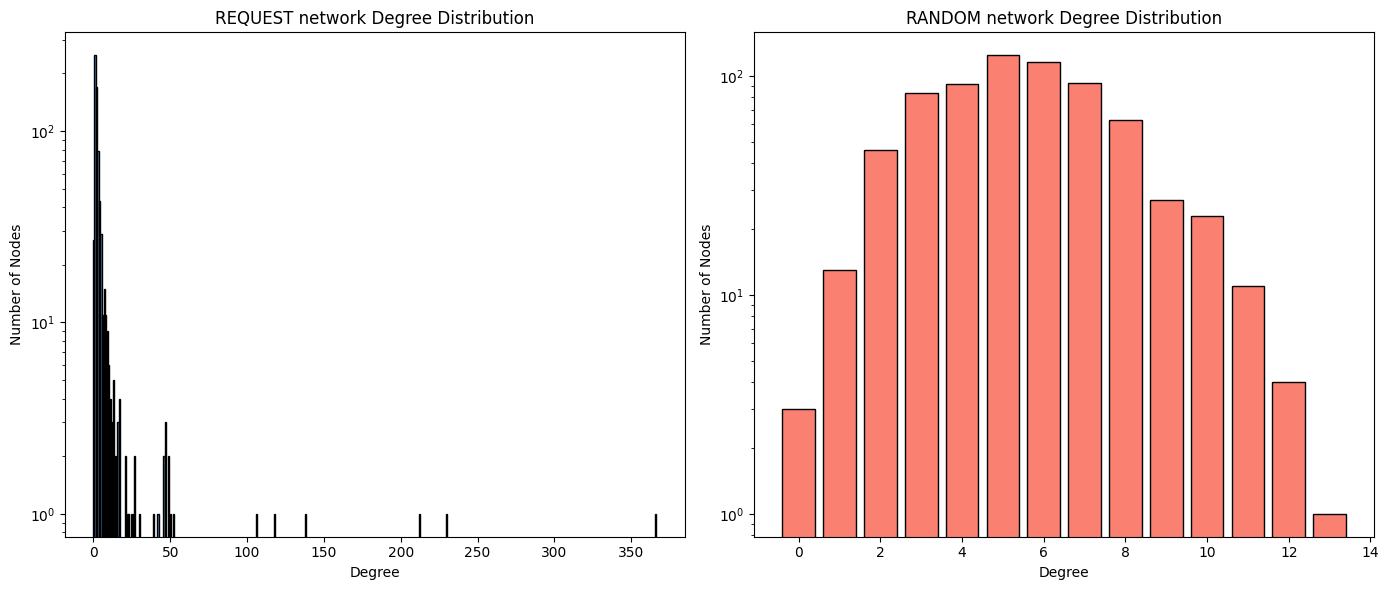

In [131]:
#RANDOM NETWORK COMPARISONS FOR REQUEST DATASET
# calculate the probability for this dataset

# Parameters from your real network
n = 698
p = 0.007745022671868384

# Create Erdős–Rényi random graph
G_random = nx.erdos_renyi_graph(n=n, p=p)

# Compute metrics
rand_nodes = num_of_nodes(G_random)
rand_edges = num_of_edges(G_random)
rand_clustering = cluster_coefficient(G_random)

# Largest connected component for path length
largest_cc = max(nx.connected_components(G_random), key=len)
G_lcc = G_random.subgraph(largest_cc)
rand_path_length = avg_shortest_path(G_lcc)
avg_shortest_path(G_random)

rand_components = nx.number_connected_components(G_random)

print("Random Graph Metrics:")
print("Nodes:", rand_nodes)
print("Edges:", rand_edges)
print("Clustering coefficient:", rand_clustering)
print("Average path length:", rand_path_length)
print("Number of components:", rand_components)
print("Edge Density: ",get_edge_density(G_random))


# ----------- PLOT HISTOGRAMS --------------------

# --- Degree histograms ---
req_hist = nx.degree_histogram(request_graph)
rand_hist = nx.degree_histogram(G_random)

# --- X‑axes (degree values) ---
req_x = list(range(len(req_hist)))
rand_x = list(range(len(rand_hist)))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(req_x, req_hist, color='steelblue', edgecolor='black')
plt.title("REQUEST network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 


plt.subplot(1, 2, 2)
plt.bar(rand_x, rand_hist, color='salmon', edgecolor='black')
plt.title("RANDOM network Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.yscale("log") 

plt.tight_layout()
plt.show()


# Task C
# Definition of a Troll
### - they post many comments on the same page and same thread
### - many other users reply to them
### - this happens more frequently than usual for that user
### - two such users show this behaviour on the same day


In [132]:
#this should find Two randomly chosen editors within the same discussion event.
#-----USERS DATASET---------------------

#COUNT of HOW MANY COMMENTS A USER MADE (by USERNAME columns)
#df_users['count']= df_users.groupby(['page_name', 'thread_subject', 'username'])['username'].transform('count')

#COUNT OF HOW MANY OTHER USERS REPLIED IN THE SAME THREAD
#THIS DOES NOT COUNT THE USERNAME OF THE PERSON WHO POSTED
#NEED TO STRIP THE PAGENAME COLUMN TO ONLY INCLUD THE MIDDLE PART THAT IS THE USERANAME

#stripping down the page_name column to get the username of the talkpage we need:
# extract the middle part: everything between "Usertalk" and ".json"
#creates a new column called page_owner





In [133]:
#an interaction event is when a "page_owner" (of a page_name) creates a "thread_subject"
#represents a single conversation thread on a single users talk page

##########################################################################
#z-score This detects users who comment much more than others in the same thread.
##########################################################################
def priority_list(G, suspicious_users, top_k=20):
    # shortest path distance from suspicious users ([u1,u2]) to every other editor
    lengths = nx.multi_source_dijkstra_path_length(G, sources=suspicious_users)
    #get the degree of every editor
    deg = dict(G.degree(weight="weight"))
    #compute score: 
        # high scores for editors who are close and well connected
        #low scores for editors who are far away or isolated
    scores = {}
    for v in G.nodes():
        if v in suspicious_users:
            continue
        if v not in lengths:
            continue
        dist = lengths[v]
        scores[v] = (1 / (1 + dist)) * (deg[v] + 1)
    #sorts and returns the top "k" editors
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


def weighted_overlap(G, u, v):
    neigh_u = set(G[u])
    neigh_v = set(G[v])
    common = neigh_u & neigh_v
    if not common:
        return 0
    return sum(G[u][x]["weight"] + G[v][x]["weight"] for x in common)


#THIS FUNCTION Counts how many comments each user makes per event
def user_event_count(df):
    df["user_event_count"] = df.groupby(
        ["page_name", "thread_subject", "username"]
    )["username"].transform("count")
    return df


#this function counts how many unique users participate in the interaction event

def size_of_interaction_event(df):
    event_sizes = df.groupby(["page_name", "thread_subject"])["username"].nunique()
    df["event_user_count"] = df.set_index(
        ["page_name", "thread_subject"]
    ).index.map(event_sizes)
    return df


#calculate the median number of comments in an event 
# and if a username has posted more than the median for that thread then they are flagged as a "troll"
#returns a list of "troll" users per event
def troll_flagging(df):
    df["event_user_event_median"] = df.groupby(
        ["page_name", "thread_subject"]
    )["user_event_count"].transform("median")

    df["event_size_median"] = df.groupby(
        ["page_name", "thread_subject"]
    )["event_user_count"].transform("median")

    df["is_troll"] = (
        #(df["user_event_count"] >= df["event_user_event_median"]) &
        (df["event_user_count"] >= df["event_size_median"])
    )
    return df


#we need to RANDOMLY select two editors per event....

def select_random_two(df):
    event_users = df["username"].unique()
    if len(event_users) < 2: #IF THERE ARE LESS THAN 2 USERS, THEN RETURN NONE
        return None, None
    return random.sample(list(event_users), 2)


#from those randomly selected two editors, check if they are suspicious
#df = troll_flagging(df) #creates a "is_troll" column
def troll_check(df):
    u1, u2 = select_random_two(df)

    if u1 is None or u2 is None:
        return False, None, None

    u1_is_troll = df.loc[df["username"] == u1, "is_troll"].any()
    u2_is_troll = df.loc[df["username"] == u2, "is_troll"].any()

    both_trolls = u1_is_troll and u2_is_troll
    return both_trolls, u1, u2

from functools import lru_cache

# Cache weighted shortest paths so they are computed only once per pair
@lru_cache(maxsize=None) # memory Cache to speed up the process of experimentation
def weighted_distance(u1, u2, G):
    return nx.shortest_path_length(
        G,
        u1,
        u2,
        weight=lambda u, v, d: 1 / d["weight"]
    )





In [134]:


#Troll check main function
def propagation_plausibility(G, u1, u2, df_event,  neighbors, r=3):
    result = {}

    # 1. check if both users are in the same component
    try:
        same_component = (
            nx.node_connected_component(G, u1)
            == nx.node_connected_component(G, u2)
        )
    except KeyError:
        same_component = False

    result["same_component"] = same_component

    if not same_component:
        result["distance"] = float("inf")
        result["cascade_score"] = 0
        result["similar_editors"] = 0
        return result

    # 2. Weighted shortest path (cached)
    distance = weighted_distance(u1, u2,G)
    result["distance"] = distance

    # 3. Weighted structural similarity
    similarity = weighted_overlap(G, u1, u2)
    result["similar_editors"] = similarity

    # 4. Cascading potential
    deg_u1 = G.degree(u1, weight="weight")
    deg_u2 = G.degree(u2, weight="weight")

    clust_u1 = nx.clustering(G, u1)
    clust_u2 = nx.clustering(G, u2)

    cascade_score = (
        (deg_u1 + deg_u2) / 2
        * (clust_u1 + clust_u2) / 2
        * (1 / (distance + 1))
        #* (1 + len(all_paths_sorted))
    )
    result["cascade_score"] = cascade_score

    # 5. Neighbourhood activation (using precomputed neighbours)
    neigh_u1 = neighbors[u1]
    neigh_u2 = neighbors[u2]

    suspicious_neighbors_u1 = df_event[
        df_event["username"].isin(neigh_u1)
    ]["is_troll"].any()

    suspicious_neighbors_u2 = df_event[
        df_event["username"].isin(neigh_u2)
    ]["is_troll"].any()

    result["suspicious_neighbors_u1"] = suspicious_neighbors_u1
    result["suspicious_neighbors_u2"] = suspicious_neighbors_u2

    return result


In [135]:
#----------FINAL LOOP FOR RANDOMLY CHECKING IF TWO USERS ARE TROLLS-----------------------
"""
    Run the full troll-propagation pipeline on any Wiki dataset.

    Parameters: 
    df : pd.DataFrame
        A wiki dataset containing page_name, thread_subject, username, etc.
    project_graph : networkx.Graph
        The weighted user interaction graph.
    top_k : int
        Number of priority editors to return. 
    
    Returns: 
    pd.DataFrame - A DataFrame of propagation plausibility results.
    """
def compute_propagation_data(df, project_graph, top_k=20):

    # -------------------------
    # 1. Preprocessing
    # -------------------------
    df = user_event_count(df)
    df = size_of_interaction_event(df)
    df = troll_flagging(df)

    results = []
    neighbors = {n: set(project_graph.neighbors(n)) for n in project_graph.nodes()}

    # -------------------------
    # 2. Loop through events
    # -------------------------
    for (owner, thread), df_event in df.groupby(["page_name", "thread_subject"]):

        both_trolls, u1, u2 = troll_check(df_event)
        if not both_trolls:
            continue

        # All trolls in this event
        event_trolls = df_event.loc[df_event["is_troll"], "username"].unique()

        # Propagation plausibility metrics
        metrics = propagation_plausibility(project_graph, u1, u2, df_event,neighbors)

        # Priority list of editors to inspect next
        priority = priority_list(project_graph, [u1, u2], top_k=top_k)

        # Store results
        results.append({
            "page_owner": owner,
            "thread_subject": thread,
            "user1": u1,
            "user2": u2,
            "event_trolls": event_trolls,
            **metrics,
            "priority_list": priority
        })

    return pd.DataFrame(results)

In [137]:
#results from the PROJECT dataset
results_project = compute_propagation_data(df_project, project_graph)


In [138]:
# results from the REQUEST_A_QUERY dataset
results_request = compute_propagation_data(df_request, request_graph)

In [ ]:
# results from the USERS dataset
results_users = compute_propagation_data(df_users, users_graph)

### Cascade_Score:
This highlights the events where:
- the two trolls were close in the network
- had strong weighted ties
- had high clustering
- had suspicious neighbours
Basically: the most plausible “outbreaks”.


### event_trolls
all trolls involved in each event

This helps us to understand the local cluster of unusual activity.


In [139]:
results_project.iloc[:]

,page_owner,thread_subject,user1,user2,event_trolls,same_component,distance,similar_editors,cascade_score,suspicious_neighbors_u1,suspicious_neighbors_u2,priority_list
0,WikidatatalkWikiProject20thCenturyPressArchive...,Integration of {{Q|36948990}}'s country/subje...,Jneubert,Jura1,"[Jneubert, Jura1]",True,0.500000,123,56.883257,True,True,"[(VIGNERON, 285.5), (Succu, 209.66666666666666..."
1,WikidatatalkWikiProject3L.json,Bac à sable ou brouillon,Simon Villeneuve,Gisele-henne,"[Simon Villeneuve, Gisele-henne]",True,0.333333,2,7.479396,True,True,"[(Succu, 209.66666666666666), (Jura1, 207.25),..."
2,WikidatatalkWikiProject3L.json,Photos,24.226.204.238,Simon Villeneuve,"[24.226.204.238, Gisele-henne, Simon Villeneuve]",True,1.000000,4,4.684066,True,True,"[(Succu, 209.66666666666666), (Jura1, 207.25),..."
3,WikidatatalkWikiProject3L.json,Questions relatives aux femmes artistes des L...,Gisele-henne,Simon Villeneuve,"[Gisele-henne, Simon Villeneuve]",True,0.333333,2,7.479396,True,True,"[(Succu, 209.66666666666666), (Jura1, 207.25),..."
4,WikidatatalkWikiProject3L.json,Redirection,Simon Villeneuve,Joachat,"[Joachat, Simon Villeneuve]",True,1.000000,0,0.782967,True,True,"[(Succu, 209.66666666666666), (Jura1, 207.25),..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3371,WikidatatalkWikiProjectsumofallpaintingsCreato...,Nice query,Jheald,Multichill,"[Jheald, Multichill]",True,0.076923,298,31.183317,True,True,"[(VIGNERON, 285.5), (Jura1, 276.3333333333333)..."
3372,WikidatatalkWikiProjectsumofallpaintingsCreato...,Query tweak suggestion,Multichill,Jheald,"[Jheald, Multichill]",True,0.076923,298,31.183317,True,True,"[(VIGNERON, 285.5), (Jura1, 276.3333333333333)..."
3373,WikidatatalkWikiProjectsumofallpaintingsDuplic...,False positives,Jane023,Multichill,"[Zolo, Multichill, Hsarrazin, Shonagon, Jane023]",True,0.020000,398,36.796264,True,True,"[(VIGNERON, 285.5), (Jura1, 276.3333333333333)..."
3374,WikidatatalkWikiProjectsumofallpaintingsLocati...,Mitä pitää tehdä?,Susannaanas,Multichill,"[Multichill, Susannaanas]",True,0.310909,129,23.983799,True,True,"[(VIGNERON, 285.5), (Jura1, 276.3333333333333)..."


In [140]:
results_request.iloc[:]

,page_owner,thread_subject,user1,user2,event_trolls,same_component,distance,similar_editors,cascade_score,suspicious_neighbors_u1,suspicious_neighbors_u2,priority_list
0,WikidataRequestaquery.json,\t Clergy houses and Manses in Norway,Tagishsimon,Pmt,"[Pmt, Tagishsimon]",True,0.062500,328,112.988805,True,True,"[(Jura1, 235.66666666666666), (Dipsacus fullon..."
1,WikidataRequestaquery.json,Access to QID or creation date,Fidoez,Jura1,"[Fidoez, Jura1]",True,1.000000,0,3.259831,True,True,"[(Tagishsimon, 365.3333333333333), (Dipsacus f..."
2,WikidataRequestaquery.json,Aggregation q,Docuracy,Tagishsimon,"[Tagishsimon, Docuracy]",True,1.000000,0,1.852100,True,True,"[(Jura1, 235.66666666666666), (Dipsacus fullon..."
3,WikidataRequestaquery.json,Display Commonscat but not from P373,Robotje,Tagishsimon,"[Robotje, Tagishsimon]",True,1.000000,0,1.852100,True,True,"[(Jura1, 235.66666666666666), (Dipsacus fullon..."
4,WikidataRequestaquery.json,How to get a list of people who have {{P|1559...,Jura1,Larske,"[Doraemonplus, Jura1, Larske]",True,0.032346,629,25.013330,True,True,"[(Tagishsimon, 365.3333333333333), (Dipsacus f..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1981,WikidataRequestaqueryArchive202111.json,List of teachers and the Querybuilder,Tagishsimon,Streetmathematician,"[Pmt, Streetmathematician, Tagishsimon, Dipsac...",True,0.500000,186,149.280732,True,True,"[(Jura1, 353.5), (Dipsacus fullonum, 341.0), (..."
1982,WikidataRequestaqueryArchive202111.json,Otherwise great query returns duplicate results,Quesotiotyo,Tagishsimon,"[Mill 1, Tagishsimon, Quesotiotyo]",True,0.250000,12,113.384990,True,True,"[(Jura1, 235.66666666666666), (Dipsacus fullon..."
1983,WikidataRequestaqueryArchive202111.json,People born from 1900-1939 with images on Wik...,Vaticidalprophet,Streetmathematician,"[Vaticidalprophet, Jura1, Streetmathematician,...",True,1.000000,5,2.025000,True,True,"[(Tagishsimon, 548.0), (Jura1, 353.5), (Dipsac..."
1984,WikidataRequestaqueryArchive202111.json,Year columns and total for year?,Tagishsimon,Chidgk1,"[Chidgk1, Tagishsimon]",True,0.511905,103,184.181137,True,True,"[(Jura1, 235.66666666666666), (Dipsacus fullon..."


In [ ]:
results_users.iloc[:]

,page_owner,thread_subject,user1,user2,event_trolls,same_component,distance,similar_editors,cascade_score,suspicious_neighbors_u1,suspicious_neighbors_u2,priority_list
0,Usertalk06Ivonne.json,Request,31.200.11.247,Pule isaac thambisa,"[31.200.11.247, Pule isaac thambisa]",True,1.000000,0,0.000000,True,True,[]
1,Usertalk0x010C.json,Create lexemes ?,0x010C,VIGNERON,"[Jura1, 0x010C, VIGNERON, KaMan]",True,0.383333,41,58.383283,True,True,"[(Infovarius, 590.0), (Jura1, 532.666666666666..."
2,Usertalk0x010C.json,Lingua Libre Bot stoped,KaMan,0x010C,"[KaMan, 0x010C]",True,0.250000,21,11.516415,True,True,"[(Infovarius, 590.0), (Jura1, 532.666666666666..."
3,Usertalk0x010C.json,Naming convention for audio files,Jura1,KaMan,"[KaMan, 0x010C, Jura1, VIGNERON]",True,0.142857,219,76.482773,True,True,"[(Infovarius, 393.3333333333333), (Multichill,..."
4,Usertalk0x010C.json,Pronunciations,0x010C,Infovarius,"[Infovarius, 0x010C]",True,0.367816,51,107.985532,True,True,"[(Jura1, 532.6666666666666), (Multichill, 337...."
...,...,...,...,...,...,...,...,...,...,...,...,...
23769,Usertalk콩가루.json,번역 알림: Wikidata:WikiProject Canada,Anonymous_username_1450,Anonymous_username_1451,"[Anonymous_username_1450, Anonymous_username_1...",True,1.000000,2,1.000000,True,True,"[(Anonymous_username_1452, 1.5)]"
23770,Usertalk콩가루.json,서명,Hym411,콩가루,"[Hym411, 콩가루]",True,0.291667,48,13.293236,True,True,"[(Jura1, 532.6666666666666), (Ivan A. Krestini..."
23771,Usertalk콩가루.json,"Congratulations, Dear Administrator!",AmaryllisGardener,Jianhui67,"[Ymblanter, AmaryllisGardener, 콩가루, Jianhui67]",True,0.166667,108,16.152975,True,True,"[(Jura1, 799.0), (Infovarius, 590.0), (Multich..."
23772,Usertalk콩가루.json,New properties,콩가루,Tobias1984,"[Tobias1984, 콩가루]",True,0.518398,24,24.446973,True,True,"[(Jura1, 532.6666666666666), (Multichill, 506...."


In [ ]:
import numpy as np
def analyse_all(results_users, results_request, results_project):
    analyse_results("USERS", results_users)
    analyse_results("REQUEST_A_QUERY", results_request)
    analyse_results("PROJECT", results_project)

def analyse_results(name, df):
    print(f"\n{name.upper()} DATASET\n")

    # Replace infinities for safe averaging
    df = df.copy()
    df["distance"] = df["distance"].replace([float("inf"), float("nan")], None)

    # 1. Average distance
    avg_dist = df["distance"].dropna().mean()
    print(f"Average shortest-path distance: {avg_dist:.3f}")

    # 2. Average weighted overlap
    avg_overlap = df["similar_editors"].mean()
    print(f"Average weighted neighbour overlap: {avg_overlap:.3f}")

    # 3. Average cascade score
    avg_cascade = df["cascade_score"].mean()
    print(f"Average cascade score: {avg_cascade:.3f}")

    # 4. Suspicious neighbour activation
    sus_u1 = df["suspicious_neighbors_u1"].mean()
    sus_u2 = df["suspicious_neighbors_u2"].mean()
    print(f"Suspicious neighbours (u1): {sus_u1:.3f}")
    print(f"Suspicious neighbours (u2): {sus_u2:.3f}")

    # 5. Priority list size
    avg_priority = df["priority_list"].apply(len).mean()
    print(f"Average priority list length: {avg_priority:.3f}")

    # 6. Component connectivity
    comp_ratio = df["same_component"].mean()
    print(f"Proportion of troll pairs in same component: {comp_ratio:.3f}")

    print("\n-----------------------------------------------------------\n")

In [ ]:
analyse_all(results_users, results_request, results_project)



USERS DATASET

Average shortest-path distance: 0.579
Average weighted neighbour overlap: 84.858
Average cascade score: 19.222
Suspicious neighbours (u1): 1.000
Suspicious neighbours (u2): 1.000
Average priority list length: 19.771
Proportion of troll pairs in same component: 1.000

-----------------------------------------------------------


REQUEST_A_QUERY DATASET

Average shortest-path distance: 0.405
Average weighted neighbour overlap: 217.071
Average cascade score: 61.883
Suspicious neighbours (u1): 1.000
Suspicious neighbours (u2): 1.000
Average priority list length: 19.970
Proportion of troll pairs in same component: 1.000

-----------------------------------------------------------


PROJECT DATASET

Average shortest-path distance: 0.441
Average weighted neighbour overlap: 106.021
Average cascade score: 26.950
Suspicious neighbours (u1): 1.000
Suspicious neighbours (u2): 1.000
Average priority list length: 19.898
Proportion of troll pairs in same component: 1.000

------------

### 

In [ ]:
#USE THIS FOR FURTHER ANALYSATION IN EXCEL
results_project.to_excel("PROJECT_propagation_results.xlsx", index=False)
results_request.to_excel("REQUEST_a_QUERY_propagation_results.xlsx", index=False)
results_users.to_excel("USERS_propagation_results.xlsx", index=False)
